In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Prepared Data Files

In [10]:
# Display current directory contents
import os
print("Files in current directory:")
files = [f for f in os.listdir('.') if f.endswith('.csv') or f.endswith('.txt')]
for file in sorted(files):
    print(f"  • {file}")

print("\n" + "="*60)

# Load all prepared data files
print("Loading data files...")

# Load Zip3 mapping
zip3_map = pd.read_csv('zip3_mapping.csv')
print(f"✓ zip3_mapping.csv: {len(zip3_map)} zip3 mappings")

# Load DAT master reference
dat_master = pd.read_csv('DAT_master_reference.csv')
print(f"✓ DAT_master_reference.csv: {len(dat_master):,} rate records")

# Load cleaned MPACT data
mpact_df = pd.read_csv('mpact_cleaned.csv')
print(f"✓ mpact_cleaned.csv: {len(mpact_df):,} MPACT records")

# Filter DAT to only include fuel rates (to match MPACT)
dat_fuel = dat_master[dat_master['fuel_included'] == True]
print(f"✓ DAT rates with fuel: {len(dat_fuel):,} records")

print("\nData loading complete!")

Files in current directory:
  • DAT_master_reference.csv
  • DAT_summary.csv
  • freight_summary_powerbi.csv
  • freight_summary_with_fuel_powerbi.csv
  • fuel_surcharge_detailed.csv
  • mpact_cleaned.csv
  • mpact_summary.txt
  • zip3_mapping.csv

Loading data files...
✓ zip3_mapping.csv: 25 zip3 mappings
✓ DAT_master_reference.csv: 13,050 rate records
✓ mpact_cleaned.csv: 360 MPACT records
✓ DAT rates with fuel: 6,525 records

Data loading complete!


## Initial Data Exploration

In [11]:
# Display MPACT data structure
print("MPACT Data Columns:")
for col in mpact_df.columns:
    print(f"  • {col}")

print(f"\nMPACT Data Shape: {mpact_df.shape}")
print(f"Unique lanes: {mpact_df[['origin_zip3', 'destination_zip3']].drop_duplicates().shape[0]}")
print(f"Unique origin states: {mpact_df['origin_state'].nunique()}")
print(f"Unique destination states: {mpact_df['destination_state'].nunique()}")

# Display DAT data structure
print("DAT Master Reference Data:")
print(f"Equipment types: {dat_master['equipment'].unique()}")
print(f"Geography levels: {dat_master['geography'].unique()}")
print(f"Fuel included distribution: {dat_master['fuel_included'].value_counts().to_dict()}")

# Show sample of DAT state rates (with fuel)
dat_sample = dat_fuel[dat_fuel['geography'] == 'state'].head(10)
print("\nSample DAT State Rates (with fuel):")
display(dat_sample)

# Summary statistics for MPACT data
if 'average' in mpact_df.columns:
    print("MPACT Rate Statistics:")
    print(mpact_df['average'].describe())
    
if 'orders' in mpact_df.columns:
    print("\n\nMPACT Orders Statistics:")
    print(mpact_df['orders'].describe())
    
if 'contributors' in mpact_df.columns:
    print("\n\nMPACT Contributors Statistics:")
    print(mpact_df['contributors'].describe())

MPACT Data Columns:
  • pulled_at
  • endpoint_type
  • origin_zip3
  • destination_zip3
  • trailer_type
  • carrier_type
  • include_fuel
  • include_quartiles
  • average
  • minimum
  • maximum
  • quartile1
  • quartile2
  • quartile3
  • orders
  • contributors
  • days_window
  • origin_zip3_str
  • destination_zip3_str
  • origin_state
  • destination_state

MPACT Data Shape: (360, 21)
Unique lanes: 95
Unique origin states: 0
Unique destination states: 0
DAT Master Reference Data:
Equipment types: ['flatbeds' 'reefers' 'vans']
Geography levels: ['region' 'state']
Fuel included distribution: {False: 6525, True: 6525}

Sample DAT State Rates (with fuel):


,equipment,geography,fuel_included,origin,destination,rate
2191,flatbeds,state,True,Origin - AB,Dest - AB,3.36
2192,flatbeds,state,True,Origin - AB,CO,2.76
2193,flatbeds,state,True,Origin - AB,ON,2.21
2194,flatbeds,state,True,Origin - AB,TX,2.05
2195,flatbeds,state,True,Origin - AB,WY,2.96
2196,flatbeds,state,True,AL,AL,3.29
2197,flatbeds,state,True,AL,AR,2.79
2198,flatbeds,state,True,AL,AZ,2.48
2199,flatbeds,state,True,AL,CA,2.33
2200,flatbeds,state,True,AL,CO,3.31


MPACT Rate Statistics:
count   360.00
mean      2.94
std       1.11
min       1.02
25%       2.13
50%       2.77
75%       3.55
max       8.35
Name: average, dtype: float64


MPACT Orders Statistics:
count   360.00
mean     23.85
std      24.74
min       5.00
25%      10.00
50%      16.00
75%      27.00
max     209.00
Name: orders, dtype: float64


MPACT Contributors Statistics:
count   360.00
mean      7.82
std       3.83
min       5.00
25%       5.00
50%       7.00
75%       9.00
max      27.00
Name: contributors, dtype: float64


## Lane-by-Lane Market Comparison

In [12]:
# Function to match MPACT lanes with DAT rates
def match_lane_with_dat(row, dat_df):
    """Match a single MPACT lane with DAT rates"""
    origin_state = row['origin_state']
    dest_state = row['destination_state']
    
    if pd.isna(origin_state) or pd.isna(dest_state):
        return None
    
    # Get DAT rates for this state-to-state lane
    dat_matches = dat_df[
        (dat_df['geography'] == 'state') &
        (dat_df['origin'] == origin_state) &
        (dat_df['destination'] == dest_state)
    ]
    
    if len(dat_matches) == 0:
        return None
    
    return dat_matches

print("Starting lane-by-lane market comparison...")

# Process each MPACT lane
lane_analysis_records = []
unmatched_lanes = []

for idx, row in mpact_df.iterrows():
    origin_state = row['origin_state']
    dest_state = row['destination_state']
    
    if pd.isna(origin_state) or pd.isna(dest_state):
        unmatched_lanes.append((row['origin_zip3'], row['destination_zip3']))
        continue
    
    dat_matches = match_lane_with_dat(row, dat_fuel)
    
    if dat_matches is None or len(dat_matches) == 0:
        unmatched_lanes.append((row['origin_zip3'], row['destination_zip3']))
        continue
    
    # Get best DAT rate for this lane
    best_dat_rate = dat_matches['rate'].max()
    best_equipment = dat_matches.loc[dat_matches['rate'].idxmax(), 'equipment']
    
    # Get MPACT rate
    mpact_rate = row.get('average', 0)
    
    # Calculate premium/discount
    if mpact_rate > 0:
        premium_pct = ((mpact_rate / best_dat_rate) - 1) * 100
    else:
        premium_pct = -100
    
    lane_analysis_records.append({
        'origin_zip3': row['origin_zip3'],
        'origin_state': origin_state,
        'dest_zip3': row['destination_zip3'],
        'dest_state': dest_state,
        'mpact_rate': mpact_rate,
        'dat_best_rate': best_dat_rate,
        'best_equipment': best_equipment,
        'premium_pct': premium_pct,
        'orders': row.get('orders', 0),
        'contributors': row.get('contributors', 0),
        'lane_key': f"{row['origin_zip3']}→{row['destination_zip3']}",
        'state_lane': f"{origin_state}→{dest_state}"
    })

# Create analysis DataFrame
if lane_analysis_records:
    lane_analysis = pd.DataFrame(lane_analysis_records)
    
    # Calculate priority score
    lane_analysis['priority_score'] = (
        lane_analysis['premium_pct'].abs() * 
        np.log1p(lane_analysis['orders']) * 
        np.log1p(lane_analysis['contributors'])
    )
    
    # Sort by priority
    lane_analysis = lane_analysis.sort_values('priority_score', ascending=False)
    
    print(f"✓ Successfully analyzed {len(lane_analysis)} lanes")
    print(f"✗ Could not match {len(unmatched_lanes)} lanes to DAT data")
    
    if unmatched_lanes:
        print("\nUnmatched lanes (first 10):")
        for lane in unmatched_lanes[:10]:
            print(f"  {lane[0]} → {lane[1]}")
    
    # Display summary
    display(Markdown("### Market Position Summary"))
    
    above_market = len(lane_analysis[lane_analysis['premium_pct'] > 0])
    below_market = len(lane_analysis[lane_analysis['premium_pct'] < 0])
    at_market = len(lane_analysis[lane_analysis['premium_pct'].abs() < 1])
    
    summary_df = pd.DataFrame({
        'Metric': ['Average Premium/Discount', 'Lanes Above Market', 'Lanes Below Market', 
                    'Lanes Within 1% of Market', 'Total Lanes Analyzed'],
        'Value': [f"{lane_analysis['premium_pct'].mean():.1f}%",
                    f"{above_market:,} ({above_market/len(lane_analysis)*100:.1f}%)",
                    f"{below_market:,} ({below_market/len(lane_analysis)*100:.1f}%)",
                    f"{at_market:,} ({at_market/len(lane_analysis)*100:.1f}%)",
                    f"{len(lane_analysis):,}"]
    })
    
    display(summary_df)
    
else:
    print("✗ No lanes could be analyzed. Check your data.")

    # Save lane analysis to CSV
if 'lane_analysis' in locals():
    lane_analysis.to_csv('lane_analysis.csv', index=False)
    print(f"✓ Saved lane analysis to 'lane_analysis.csv'")
    
    # Show top 10 lanes by priority
    display(Markdown("### Top 10 Priority Lanes"))
    display(lane_analysis.head(10))

Starting lane-by-lane market comparison...
✗ No lanes could be analyzed. Check your data.


## Visualize Market Position

NameError: name 'lane_analysis' is not defined

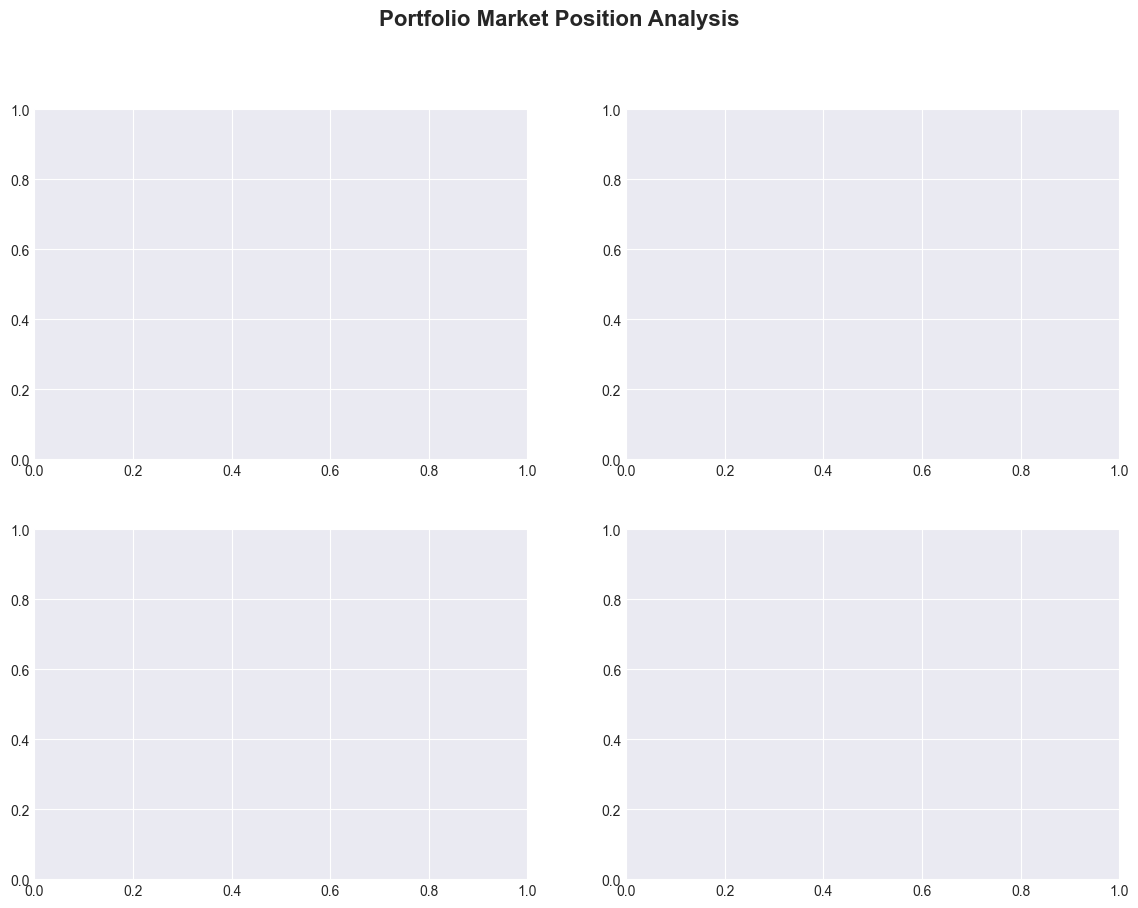

In [13]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Portfolio Market Position Analysis', fontsize=16, fontweight='bold')

# 1. Distribution of premiums
ax1 = axes[0, 0]
ax1.hist(lane_analysis['premium_pct'], bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', label='Market Rate', linewidth=2)
ax1.set_xlabel('Premium/Discount vs Market (%)')
ax1.set_ylabel('Number of Lanes')
ax1.set_title('Distribution of Market Position')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Premium vs Orders (scatter)
ax2 = axes[0, 1]
scatter = ax2.scatter(lane_analysis['premium_pct'], lane_analysis['orders'], 
                        alpha=0.6, s=50, c=lane_analysis['priority_score'], 
                        cmap='viridis')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Premium/Discount vs Market (%)')
ax2.set_ylabel('Orders (Volume)')
ax2.set_title('Market Position vs Volume (Color = Priority)')
plt.colorbar(scatter, ax=ax2, label='Priority Score')
ax2.grid(True, alpha=0.3)

# 3. Top 10 lanes by volume
ax3 = axes[1, 0]
top_10_volume = lane_analysis.nlargest(10, 'orders')
colors = ['green' if x > 0 else 'red' for x in top_10_volume['premium_pct']]
bars = ax3.barh(range(len(top_10_volume)), top_10_volume['orders'], color=colors)
ax3.set_yticks(range(len(top_10_volume)))
ax3.set_yticklabels(top_10_volume['lane_key'], fontsize=9)
ax3.set_xlabel('Number of Orders')
ax3.set_title('Top 10 Lanes by Volume\n(Green=Above Market, Red=Below Market)')
ax3.invert_yaxis()  # Highest volume at top
ax3.grid(True, alpha=0.3, axis='x')

# 4. Premium by volume quartile
ax4 = axes[1, 1]
lane_analysis['volume_quartile'] = pd.qcut(lane_analysis['orders'], 4, 
                                            labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
quartile_stats = lane_analysis.groupby('volume_quartile')['premium_pct'].mean()
bars = ax4.bar(quartile_stats.index, quartile_stats.values, 
                color=['red', 'orange', 'yellow', 'green'])
ax4.set_xlabel('Volume Quartile')
ax4.set_ylabel('Average Premium/Discount (%)')
ax4.set_title('Market Position by Volume Quartile')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold')

plt.tight_layout()
plt.savefig('market_position_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations created and saved as 'market_position_analysis.png'")

## Equipment Optimization Analysis

In [ ]:
# Analyze equipment optimization opportunities
print("Analyzing equipment optimization opportunities...")

equipment_analysis_records = []

for idx, row in lane_analysis.iterrows():
    origin_state = row['origin_state']
    dest_state = row['dest_state']
    
    # Get DAT rates for all equipment types for this lane
    dat_rates = dat_fuel[
        (dat_fuel['geography'] == 'state') &
        (dat_fuel['origin'] == origin_state) &
        (dat_fuel['destination'] == dest_state)
    ]
    
    if len(dat_rates) > 0:
        # Find equipment with highest rate
        best_idx = dat_rates['rate'].idxmax()
        best_equipment_row = dat_rates.loc[best_idx]
        best_equipment = best_equipment_row['equipment']
        best_rate = best_equipment_row['rate']
        
        # Get rates for all equipment types
        equipment_rates = {}
        for _, eq_row in dat_rates.iterrows():
            equipment_rates[eq_row['equipment']] = eq_row['rate']
        
        # Current MPACT rate
        current_rate = row['mpact_rate']
        
        # Calculate improvement opportunity
        improvement = best_rate - current_rate if current_rate > 0 else best_rate
        improvement_pct = (improvement / current_rate * 100) if current_rate > 0 else 100
        
        equipment_analysis_records.append({
            'lane_key': row['lane_key'],
            'origin_state': origin_state,
            'dest_state': dest_state,
            'current_rate': current_rate,
            'best_equipment': best_equipment,
            'best_rate': best_rate,
            'improvement_$': improvement,
            'improvement_%': improvement_pct,
            'orders': row['orders'],
            'flatbed_rate': equipment_rates.get('flatbeds', np.nan),
            'reefer_rate': equipment_rates.get('reefers', np.nan),
            'van_rate': equipment_rates.get('vans', np.nan),
            'opportunity_score': improvement * np.log1p(row['orders'])
        })

# Create equipment analysis DataFrame
if equipment_analysis_records:
    equip_df = pd.DataFrame(equipment_analysis_records)
    equip_df = equip_df.sort_values('opportunity_score', ascending=False)
    
    # Save to CSV
    equip_df.to_csv('equipment_optimization.csv', index=False)
    
    print(f"✓ Analyzed {len(equip_df)} lanes for equipment optimization")
    print(f"✓ Saved results to 'equipment_optimization.csv'")
    
    # Display summary
    display(Markdown("### Equipment Optimization Summary"))
    
    # Count lanes where different equipment would be better
    equip_summary = equip_df.groupby('best_equipment').size().reset_index(name='count')
    equip_summary['percentage'] = (equip_summary['count'] / len(equip_df) * 100).round(1)
    
    display(equip_summary)
    
    # Show top 5 opportunities
    display(Markdown("### Top 5 Equipment Optimization Opportunities"))
    top_5 = equip_df.head(5)
    
    for i, (idx, row) in enumerate(top_5.iterrows(), 1):
        print(f"{i}. {row['lane_key']}")
        print(f"   Current rate: ${row['current_rate']:.2f}/mile")
        print(f"   Best equipment: {row['best_equipment']} (${row['best_rate']:.2f}/mile)")
        print(f"   Improvement: +${row['improvement_$']:.2f}/mile (+{row['improvement_%']:.1f}%)")
        print(f"   Orders: {row['orders']:.0f}")
        print()
    
else:
    print("✗ No equipment optimization analysis could be performed")

    # Visualize equipment opportunities
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribution of improvement opportunities
ax1 = axes[0]
ax1.hist(equip_df['improvement_$'], bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Rate Improvement ($/mile)')
ax1.set_ylabel('Number of Lanes')
ax1.set_title('Distribution of Equipment Improvement Opportunities')
ax1.grid(True, alpha=0.3)

# 2. Best equipment by lane count
ax2 = axes[1]
best_equip_counts = equip_df['best_equipment'].value_counts()
bars = ax2.bar(best_equip_counts.index, best_equip_counts.values)
ax2.set_xlabel('Equipment Type')
ax2.set_ylabel('Number of Lanes')
ax2.set_title('Best Equipment Type by Lane Count')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom',
                fontweight='bold')

plt.tight_layout()
plt.savefig('equipment_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Equipment optimization visualization saved")

## Actionable Recommendations

In [ ]:
# Create lane categories based on analysis
def categorize_lane(row):
    """Categorize lane based on volume and market position"""
    orders = row['orders']
    premium = row['premium_pct']
    
    if orders > 20 and premium < -5:
        return 'A'  # High volume, slightly below market (URGENT)
    elif orders > 10 and premium < -10:
        return 'B'  # Medium volume, significantly below market
    elif premium < -15:
        return 'C'  # Very below market (regardless of volume)
    elif premium > 10:
        return 'D'  # Above market (good performance)
    else:
        return 'E'  # At or near market rate

# Apply categorization
lane_analysis['category'] = lane_analysis.apply(categorize_lane, axis=1)

# Create recommendations
recommendations = []

# Category A: High volume, slightly below market (urgent)
cat_a = lane_analysis[lane_analysis['category'] == 'A']
for idx, row in cat_a.iterrows():
    recommendations.append({
        'priority': 'HIGH',
        'action': 'Raise rates immediately',
        'lane': row['lane_key'],
        'volume': row['orders'],
        'current_rate': row['mpact_rate'],
        'market_rate': row['dat_best_rate'],
        'premium_pct': row['premium_pct'],
        'details': f"High volume ({row['orders']} orders) but {abs(row['premium_pct']):.1f}% below market",
        'target': f"Raise to ${row['dat_best_rate']:.2f}/mile (+${row['dat_best_rate'] - row['mpact_rate']:.2f})",
        'timeline': 'This week'
    })

# Category B: Medium volume, significantly below market
cat_b = lane_analysis[lane_analysis['category'] == 'B']
for idx, row in cat_b.iterrows():
    recommendations.append({
        'priority': 'MEDIUM',
        'action': 'Negotiate rate increase',
        'lane': row['lane_key'],
        'volume': row['orders'],
        'current_rate': row['mpact_rate'],
        'market_rate': row['dat_best_rate'],
        'premium_pct': row['premium_pct'],
        'details': f"Moderate volume ({row['orders']} orders), {abs(row['premium_pct']):.1f}% below market",
        'target': f"Aim for ${row['dat_best_rate'] * 0.95:.2f}/mile (5% below market)",
        'timeline': 'Next 2 weeks'
    })

# Equipment optimization opportunities
top_equip = equip_df.head(10)
for idx, row in top_equip.iterrows():
    if row['improvement_$'] > 0.25:  # Significant improvement
        recommendations.append({
            'priority': 'MEDIUM-HIGH',
            'action': 'Consider equipment change',
            'lane': row['lane_key'],
            'volume': row['orders'],
            'current_rate': row['current_rate'],
            'best_equipment': row['best_equipment'],
            'best_rate': row['best_rate'],
            'improvement': row['improvement_$'],
            'details': f"Switch to {row['best_equipment']} for +${row['improvement_$']:.2f}/mile improvement",
            'target': f"Use {row['best_equipment']} equipment on this lane",
            'timeline': 'Evaluate within 30 days'
        })

# Category D: Above market (good performance)
cat_d = lane_analysis[lane_analysis['category'] == 'D']
for idx, row in cat_d.head(5).iterrows():  # Top 5 performers
    recommendations.append({
        'priority': 'MONITOR',
        'action': 'Maintain and expand',
        'lane': row['lane_key'],
        'volume': row['orders'],
        'current_rate': row['mpact_rate'],
        'market_rate': row['dat_best_rate'],
        'premium_pct': row['premium_pct'],
        'details': f"Performing {row['premium_pct']:.1f}% above market with {row['orders']} orders",
        'target': f"Maintain current rates, consider expanding capacity",
        'timeline': 'Ongoing'
    })

# Create recommendations DataFrame
if recommendations:
    rec_df = pd.DataFrame(recommendations)
    rec_df.to_csv('action_recommendations.csv', index=False)
    
    print(f"✓ Created {len(rec_df)} actionable recommendations")
    print(f"✓ Saved to 'action_recommendations.csv'")
    
    # Display summary by priority
    display(Markdown("### Recommendations by Priority Level"))
    
    priority_summary = rec_df['priority'].value_counts().reset_index()
    priority_summary.columns = ['Priority', 'Count']
    display(priority_summary)
    
    # Show top 5 HIGH priority recommendations
    display(Markdown("### Top 5 HIGH Priority Recommendations"))
    high_priority = rec_df[rec_df['priority'] == 'HIGH'].head(5)
    display(high_priority[['lane', 'action', 'details', 'target', 'timeline']])
    
else:
    print("✗ No recommendations generated")

## Executive Summary

In [ ]:
# Generate executive summary
print("Generating executive summary...")

# Calculate key metrics
total_lanes = len(lane_analysis)
total_orders = lane_analysis['orders'].sum()
avg_premium = lane_analysis['premium_pct'].mean()

# Identify top/bottom performers
top_5_lanes = lane_analysis.nlargest(5, 'premium_pct')[['lane_key', 'premium_pct', 'orders']]
bottom_5_lanes = lane_analysis.nsmallest(5, 'premium_pct')[['lane_key', 'premium_pct', 'orders']]

# Equipment opportunities
significant_equip_opps = equip_df[equip_df['improvement_$'] > 0.25]
total_equip_opportunity = significant_equip_opps['improvement_$'].sum()

# Financial impact of below-market lanes
below_market = lane_analysis[lane_analysis['premium_pct'] < 0]
if len(below_market) > 0:
    below_market['monthly_loss'] = below_market['orders'] * (below_market['dat_best_rate'] - below_market['mpact_rate'])
    monthly_loss = below_market['monthly_loss'].sum()
else:
    monthly_loss = 0

# Create summary text
summary_text = f"""
PORTFOLIO ANALYSIS EXECUTIVE SUMMARY
{'='*60}

OVERVIEW
{'-'*60}
• Total lanes analyzed: {total_lanes:,}
• Total orders (last 30 days): {total_orders:,.0f}
• Average market position: {avg_premium:+.1f}% {'above' if avg_premium > 0 else 'below'} market

FINANCIAL IMPACT
{'-'*60}
• Estimated monthly revenue opportunity: ${monthly_loss:.2f}
• Significant equipment opportunities: {len(significant_equip_opps):,} lanes
• Potential rate improvement: ${total_equip_opportunity:.2f}/mile across all lanes

TOP PERFORMERS (Above Market)
{'-'*60}
"""
for idx, row in top_5_lanes.iterrows():
    summary_text += f"• {row['lane_key']}: {row['premium_pct']:+.1f}% above market ({row['orders']:.0f} orders)\n"

summary_text += f"""
PRIORITY AREAS (Below Market)
{'-'*60}
"""
for idx, row in bottom_5_lanes.iterrows():
    summary_text += f"• {row['lane_key']}: {row['premium_pct']:+.1f}% below market ({row['orders']:.0f} orders)\n"

summary_text += f"""
EQUIPMENT OPTIMIZATION
{'-'*60}
• Top opportunity: {equip_df.iloc[0]['lane_key']} → Switch to {equip_df.iloc[0]['best_equipment']} 
    (+${equip_df.iloc[0]['improvement_$']:.2f}/mile, +{equip_df.iloc[0]['improvement_%']:.1f}%)
• Equipment distribution: {equip_df['best_equipment'].value_counts().to_dict()}

RECOMMENDED ACTIONS
{'-'*60}
1. IMMEDIATE: Address {len(lane_analysis[lane_analysis['premium_pct'] < -10])} lanes >10% below market
2. STRATEGIC: Evaluate equipment changes on {len(significant_equip_opps)} high-opportunity lanes
3. MONITOR: Maintain performance on {len(lane_analysis[lane_analysis['premium_pct'] > 5])} lanes >5% above market

NEXT STEPS
{'-'*60}
• Review 'action_recommendations.csv' for detailed lane-by-lane actions
• Use 'lane_analysis.csv' for ongoing market position monitoring
• Schedule broker negotiations based on below-market lanes
• Re-run analysis weekly to track improvements
"""

# Save summary to file
with open('executive_summary.txt', 'w') as f:
    f.write(summary_text)

print("✓ Executive summary generated and saved to 'executive_summary.txt'")
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(summary_text)

## Final Output Summary

In [ ]:
# List all output files
print("ANALYSIS COMPLETE!")
print("="*60)
print("\nOutput Files Created:")
print("-"*60)

output_files = [
    ('lane_analysis.csv', 'Detailed lane-by-lane market comparison'),
    ('equipment_optimization.csv', 'Equipment change opportunities'),
    ('action_recommendations.csv', 'Prioritized action items'),
    ('executive_summary.txt', 'High-level findings and recommendations'),
    ('market_position_analysis.png', 'Market position visualizations'),
    ('equipment_optimization.png', 'Equipment optimization visualizations')
]

for file, description in output_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # Size in KB
        print(f"✓ {file:30} | {description}")
        print(f"  {'Size:':30} | {size:.1f} KB")
    else:
        print(f"✗ {file:30} | NOT FOUND")

print("\n" + "="*60)
print("NEXT STEPS")
print("="*60)
print("""
1. Review 'executive_summary.txt' for quick overview
2. Check 'action_recommendations.csv' - start with HIGH priority items
3. Use 'lane_analysis.csv' to prepare for broker negotiations
4. Review 'equipment_optimization.csv' for equipment change opportunities
5. Share visualizations with your team
6. Re-run analysis weekly to track improvements
""")

print("✓ Analysis completed successfully!")

## Export

In [ ]:
# Export a consolidated report in Excel format
print("Creating consolidated Excel report...")

with pd.ExcelWriter('portfolio_analysis_report.xlsx', engine='openpyxl') as writer:
    # Write lane analysis
    lane_analysis.to_excel(writer, sheet_name='Lane Analysis', index=False)
    
    # Write equipment optimization
    if 'equip_df' in locals():
        equip_df.to_excel(writer, sheet_name='Equipment Optimization', index=False)
    
    # Write recommendations
    if 'rec_df' in locals():
        rec_df.to_excel(writer, sheet_name='Action Recommendations', index=False)
    
    # Write summary statistics
    summary_stats = pd.DataFrame({
        'Metric': [
            'Total Lanes Analyzed',
            'Total Orders (30 days)',
            'Average Premium/Discount',
            'Lanes Above Market',
            'Lanes Below Market',
            'Monthly Revenue Opportunity',
            'Equipment Opportunities'
        ],
        'Value': [
            f"{total_lanes:,}",
            f"{total_orders:,.0f}",
            f"{avg_premium:+.1f}%",
            f"{len(lane_analysis[lane_analysis['premium_pct'] > 0]):,}",
            f"{len(lane_analysis[lane_analysis['premium_pct'] < 0]):,}",
            f"${monthly_loss:,.2f}",
            f"{len(significant_equip_opps):,}"
        ]
    })
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)

print("✓ Consolidated report saved as 'portfolio_analysis_report.xlsx'")
print("\n" + "="*60)
print("ANALYSIS READY FOR PORTFOLIO OPTIMIZATION!")
print("="*60)